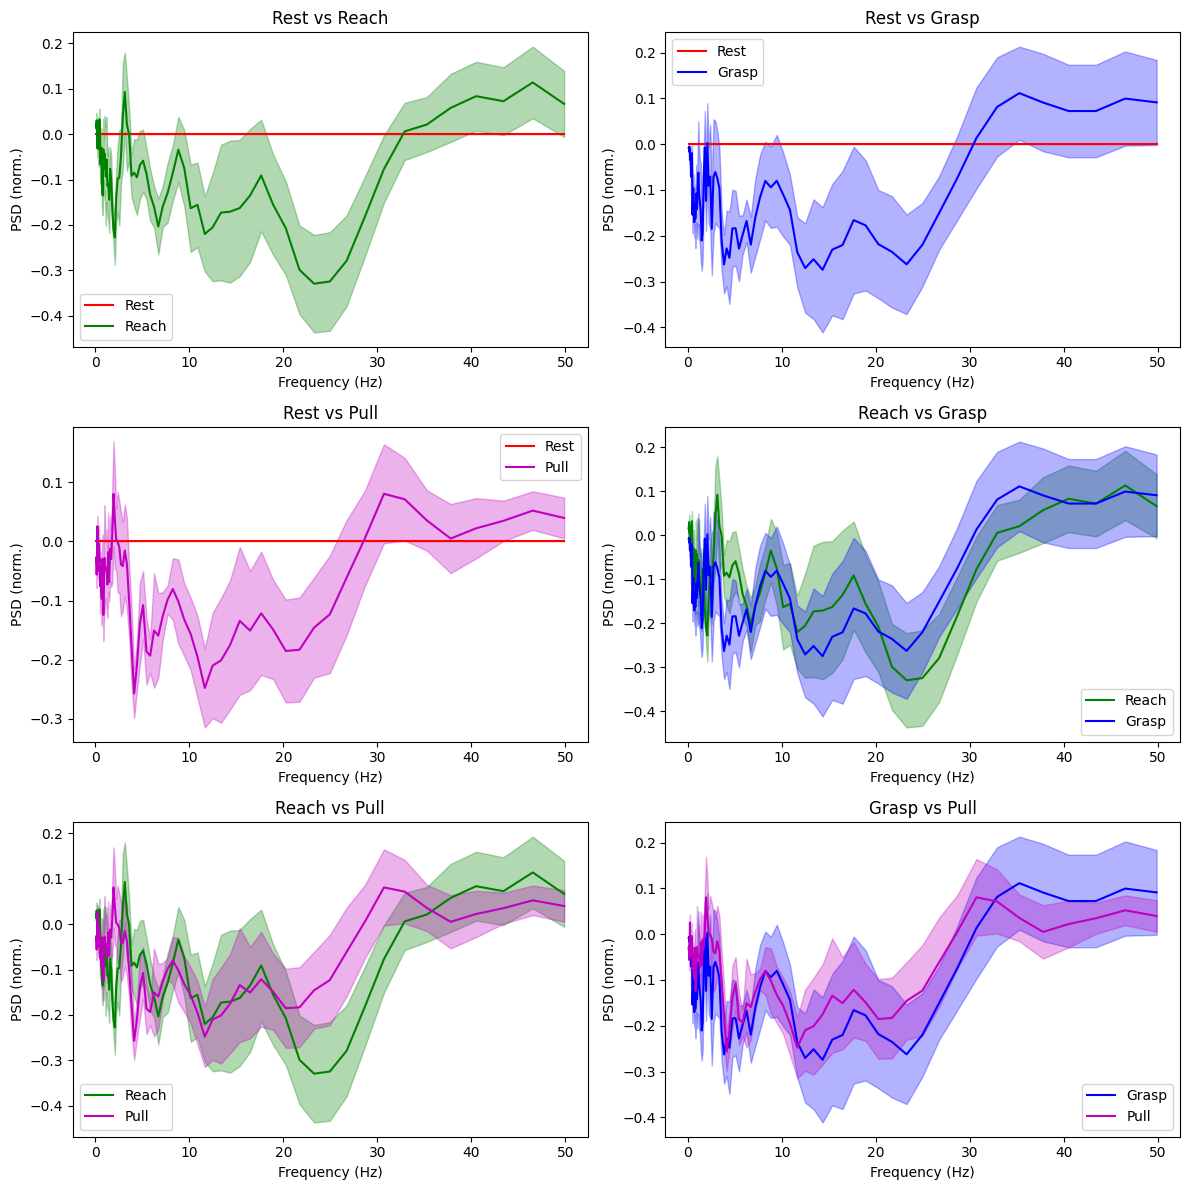

In [1]:
# SANITY CHECK IMPORT

import matplotlib.pyplot as plt
import numpy as np
import pickle
from itertools import combinations

# === Caricamento pickle ===
with open(r"C:\Users\tomma\OneDrive - University of Pisa\Desktop\TESI\Connectivity_Analysis\IMPORT_DATA\LFP_PSD_CONNECTIVITY.pkl", 'rb') as f:
    data_dict = pickle.load(f)

subject_list = list(data_dict.keys())
n_subjects = len(subject_list)
phase_names = ['Rest', 'Reach', 'Grasp', 'Pull']
n_phases = len(phase_names)

# --- Trova lunghezza frequenze minima tra i soggetti ---
min_len = min([len(data_dict[subj_id]['freqs']) for subj_id in subject_list])

# Frequenze comuni
freqs = data_dict[subject_list[0]]['freqs'][:min_len]

# Array finale [freq x subject x phase]
psd_all = np.zeros((min_len, n_subjects, n_phases))

for s_idx, subj_id in enumerate(subject_list):
    for p_idx, phase in enumerate(phase_names):
        psd_phase = data_dict[subj_id]['PSD_norm_median'][phase]
        psd_all[:, s_idx, p_idx] = psd_phase[:min_len] 

# Media e SEM tra soggetti per fase
psd_mean = np.mean(psd_all, axis=1)
psd_sem = np.std(psd_all, axis=1, ddof=1) / np.sqrt(n_subjects)

# Indici per frequenze ≤ 50 Hz
freq_mask = freqs <= 50
freqs_plot = freqs[freq_mask]
psd_mean_plot = psd_mean[freq_mask, :]
psd_sem_plot = psd_sem[freq_mask, :]

# Creiamo subplot per ogni coppia di fasi
phase_pairs = list(combinations(range(n_phases), 2))
n_pairs = len(phase_pairs)
n_cols = 2
n_rows = int(np.ceil(n_pairs / n_cols))

plt.figure(figsize=(12, n_rows*4))
colors = ['r', 'g', 'b', 'm']

for idx, (p1, p2) in enumerate(phase_pairs):
    ax = plt.subplot(n_rows, n_cols, idx+1)
    # Phase 1
    ax.plot(freqs_plot, psd_mean_plot[:,p1], color=colors[p1], label=phase_names[p1])
    ax.fill_between(freqs_plot,
                    psd_mean_plot[:,p1] - psd_sem_plot[:,p1],
                    psd_mean_plot[:,p1] + psd_sem_plot[:,p1],
                    color=colors[p1], alpha=0.3)
    # Phase 2
    ax.plot(freqs_plot, psd_mean_plot[:,p2], color=colors[p2], label=phase_names[p2])
    ax.fill_between(freqs_plot,
                    psd_mean_plot[:,p2] - psd_sem_plot[:,p2],
                    psd_mean_plot[:,p2] + psd_sem_plot[:,p2],
                    color=colors[p2], alpha=0.3)
    
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('PSD (norm.)')
    ax.set_title(f'{phase_names[p1]} vs {phase_names[p2]}')
    ax.legend()
    ax.grid(False)  # rimuove la griglia

plt.tight_layout()
plt.show()


## CBPT ALL TRIALS

Frequenze uniformi: (160,)
Rest: (239, 160)
Reach: (239, 160)
Grasp: (239, 160)
Pull: (239, 160)

✔️ Completed CBPT for all phase pairs.


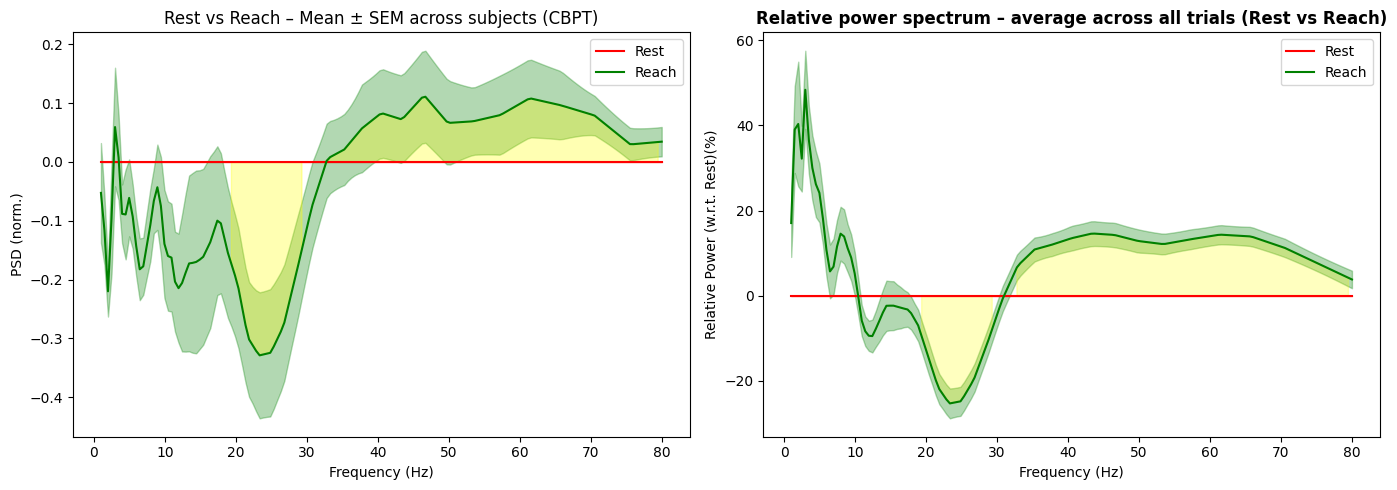


Clusters for Grasp_vs_Pull (CBPT):
  Cluster 1: 11.43-12.43 Hz  →  p = 0.433300   (n.s.)
  Cluster 2: 19.38-29.32 Hz  →  p = 0.006800   (SIGNIFICANT)
  Cluster 3: 1.00-5.47 Hz  →  p = 0.127600   (n.s.)
  Cluster 4: 7.96-8.95 Hz  →  p = 0.457100   (n.s.)
  Cluster 5: 32.80-79.50 Hz  →  p = 0.000100   (SIGNIFICANT)

------------------------------------------------------------



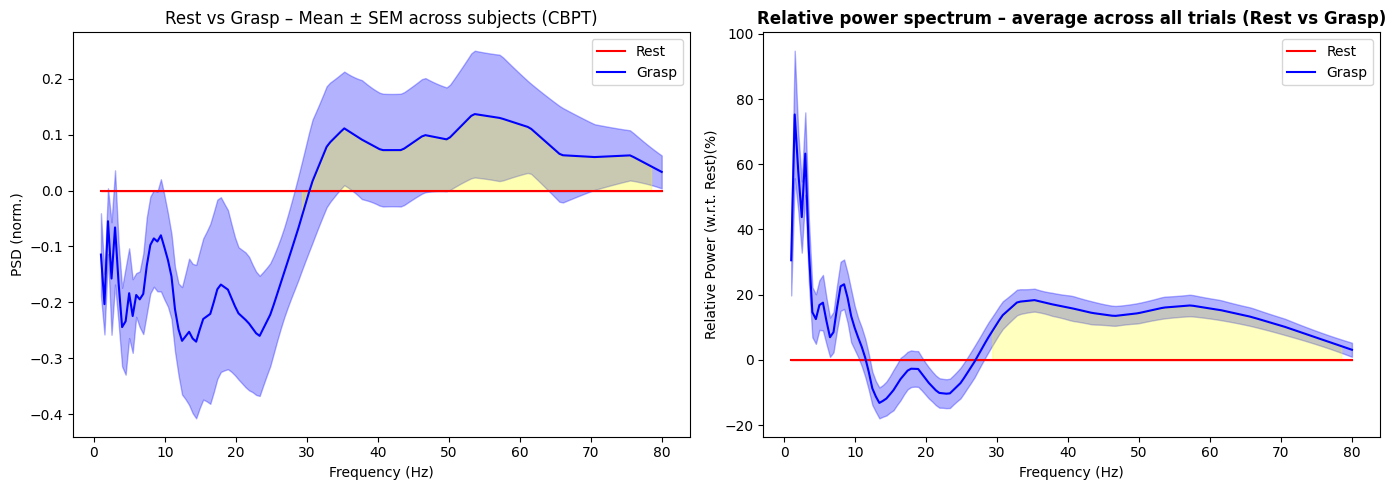


Clusters for Rest_vs_Reach (CBPT):
  Cluster 1: 12.92-14.42 Hz  →  p = 0.376700   (n.s.)
  Cluster 2: 21.37-23.86 Hz  →  p = 0.323000   (n.s.)
  Cluster 3: 1.00-3.48 Hz  →  p = 0.216200   (n.s.)
  Cluster 4: 4.97-5.47 Hz  →  p = 0.522500   (n.s.)
  Cluster 5: 7.46-8.95 Hz  →  p = 0.358600   (n.s.)
  Cluster 6: 29.32-78.51 Hz  →  p = 0.000100   (SIGNIFICANT)

------------------------------------------------------------



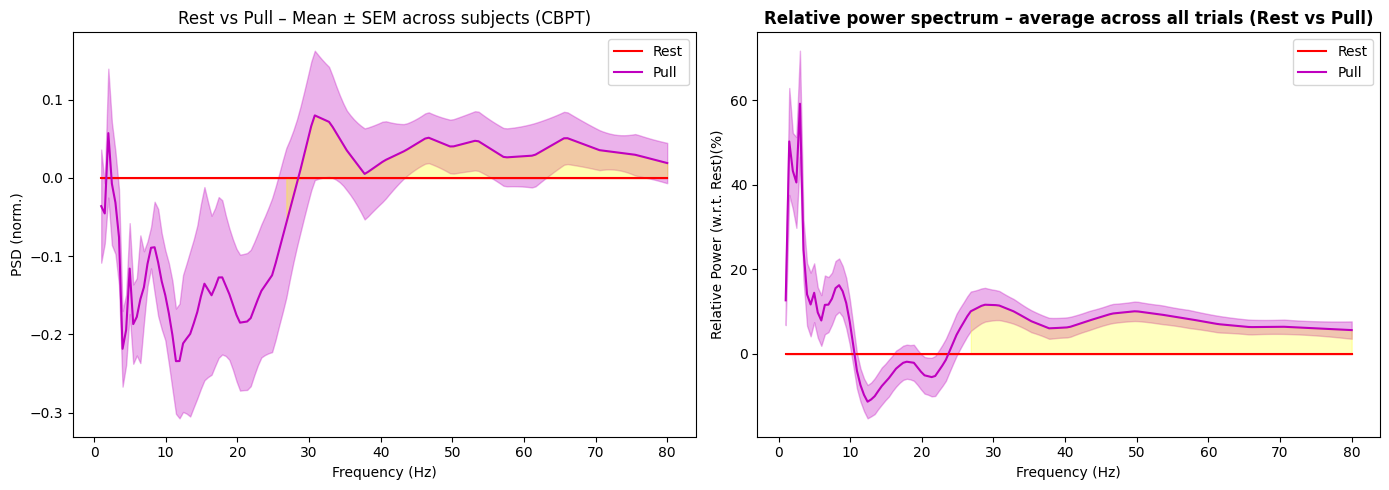


Clusters for Rest_vs_Grasp (CBPT):
  Cluster 1: 11.93-13.92 Hz  →  p = 0.364800   (n.s.)
  Cluster 2: 1.00-3.48 Hz  →  p = 0.243300   (n.s.)
  Cluster 3: 4.97-4.97 Hz  →  p = 0.685500   (n.s.)
  Cluster 4: 7.46-9.45 Hz  →  p = 0.383100   (n.s.)
  Cluster 5: 26.84-80.00 Hz  →  p = 0.000100   (SIGNIFICANT)

------------------------------------------------------------



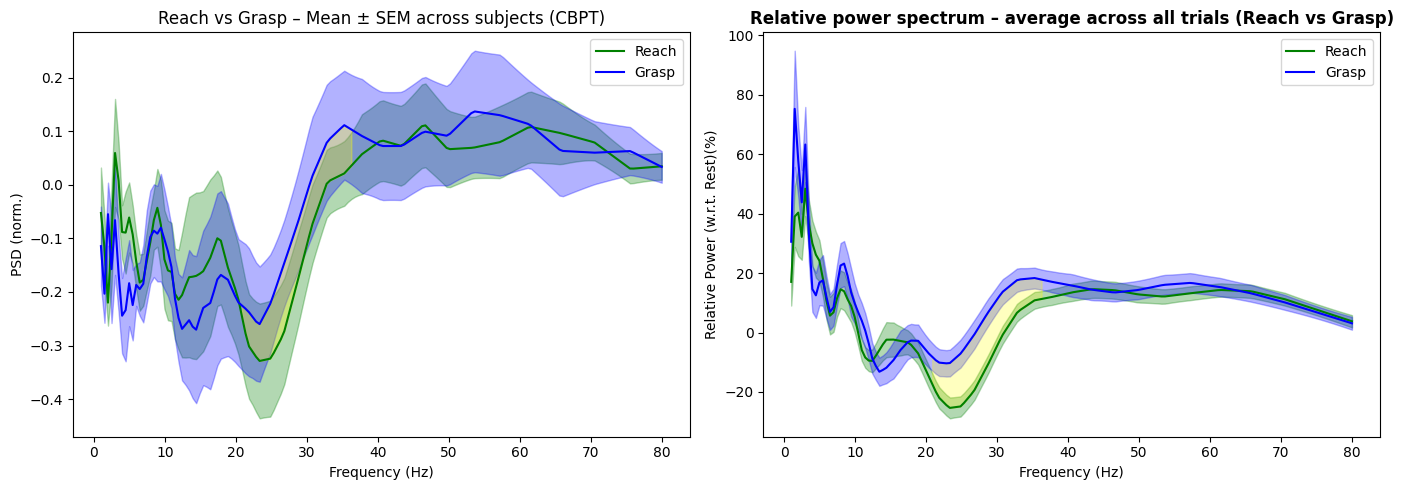


Clusters for Rest_vs_Pull (CBPT):
  Cluster 1: 1.00-1.50 Hz  →  p = 0.540300   (n.s.)
  Cluster 2: 20.87-36.28 Hz  →  p = 0.007400   (SIGNIFICANT)

------------------------------------------------------------



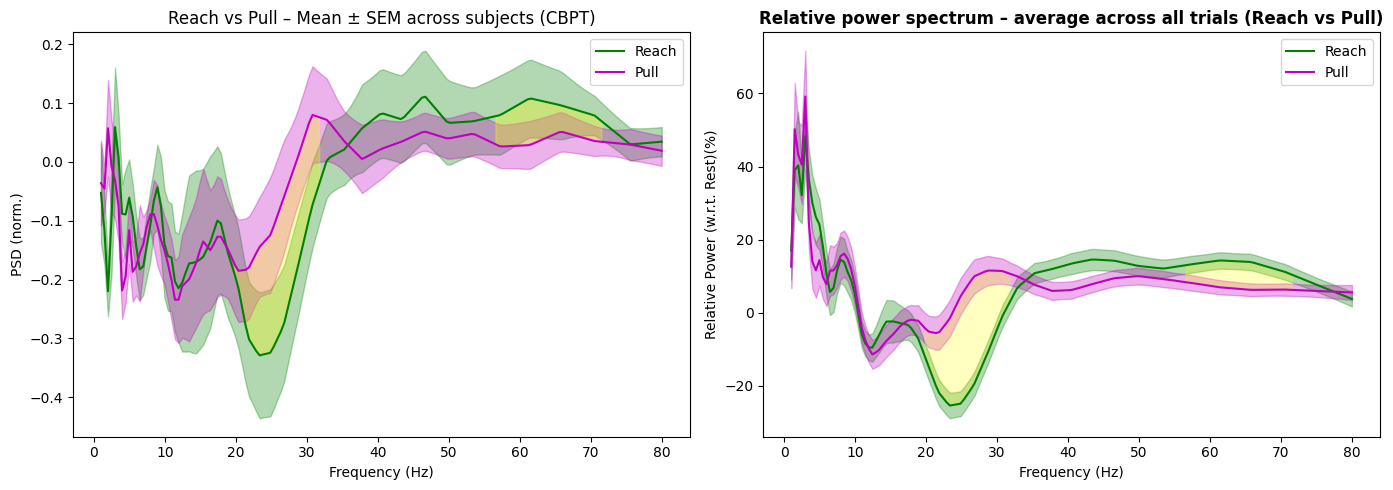


Clusters for Reach_vs_Grasp (CBPT):
  Cluster 1: 37.27-44.72 Hz  →  p = 0.126700   (n.s.)
  Cluster 2: 56.65-71.55 Hz  →  p = 0.016500   (SIGNIFICANT)
  Cluster 3: 19.88-31.81 Hz  →  p = 0.005800   (SIGNIFICANT)

------------------------------------------------------------



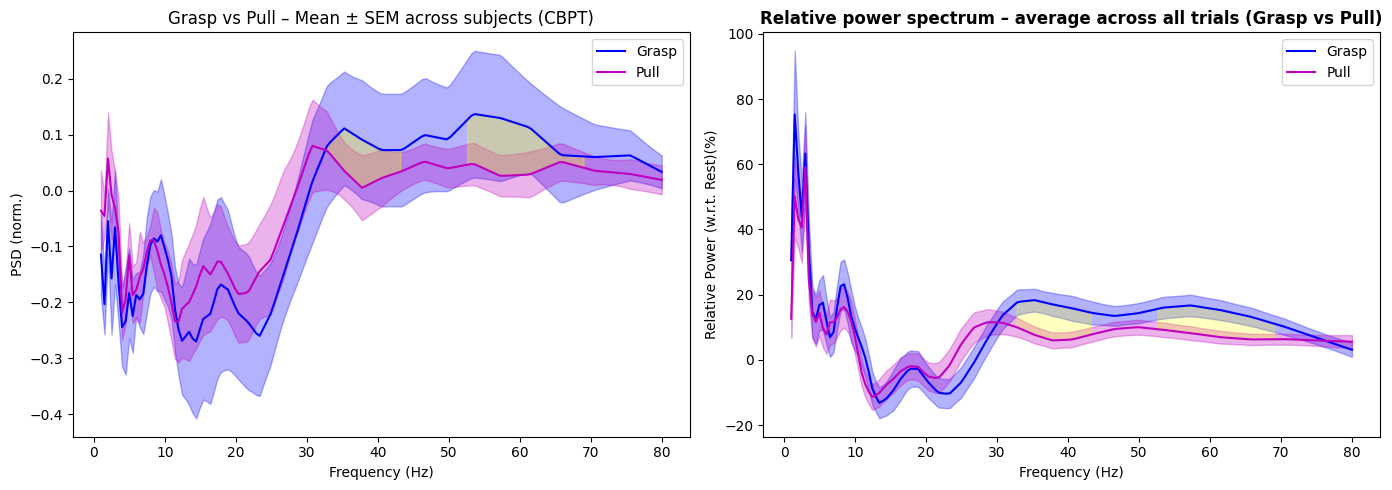


Clusters for Reach_vs_Pull (CBPT):
  Cluster 1: 1.00-1.50 Hz  →  p = 0.549700   (n.s.)
  Cluster 2: 32.80-43.23 Hz  →  p = 0.042300   (SIGNIFICANT)
  Cluster 3: 52.67-69.07 Hz  →  p = 0.019700   (SIGNIFICANT)
  Cluster 4: 23.86-27.33 Hz  →  p = 0.272200   (n.s.)

------------------------------------------------------------



In [26]:
# ============================================================
# 📊 PLOT dei risultati CBPT (adattato a freq_uniform 1-80 Hz) ---> ESEMPIO CON TRIALS NON TRIMMATI --> 
# ============================================================

# ALL TRIALS CBPT

from scipy.interpolate import interp1d
from mne.stats import permutation_cluster_1samp_test
from scipy import sparse
import scipy.stats
import itertools
import numpy as np

subject_list = list(data_dict.keys())
phase_names = ["Rest", "Reach", "Grasp", "Pull"]

# --- Build uniform frequency array (from 1 to 80 Hz)
freq_uniform = np.linspace(1, 80, 160)
n_freqs = len(freq_uniform)
print("Frequenze uniformi:", freq_uniform.shape)

# Dict for all trials
ALL_TRIALS = {p: [] for p in phase_names}

# Extraction of PSD trials 
for subject_id in subject_list:

    freqs_orig = data_dict[subject_id]['freqs_cutted']

    for phase in phase_names:
        
        # Array (n_freqs × n_trials)
        psd_phase = data_dict[subject_id]['PSD_trials_norm'][phase]

        # TCut frequencies 1–80 Hz
        freq_mask = (freqs_orig >= 1) & (freqs_orig <= 80)
        freqs_cut = freqs_orig[freq_mask]
        psd_phase_cut = psd_phase[freq_mask, :]*100   # (n_freq_cut × n_trials)
        
        # Interpolation of the PSD to the regular lattice
        n_trials = psd_phase_cut.shape[1]

        psd_interp = np.zeros((n_trials, n_freqs)) 

        for t in range(n_trials):
            f = interp1d(freqs_cut,
                         psd_phase_cut[:, t],
                         kind='linear',
                         fill_value='extrapolate')
            psd_interp[t, :] = f(freq_uniform)

        ALL_TRIALS[phase].append(psd_interp)

# Concatenation of all interpolated trials per subject and phase
for phase in phase_names:
    ALL_TRIALS[phase] = np.concatenate(ALL_TRIALS[phase], axis=0)
    print(f"{phase}: {ALL_TRIALS[phase].shape}")

# Build the adjacency matrix --> all frequencies are neighbours with the two closest ones (e.g. 2 Hz -> 1 Hz and 3 Hz )
adj = sparse.lil_matrix((n_freqs, n_freqs))

for i in range(n_freqs - 1):
    adj[i, i+1] = 1
    adj[i+1, i] = 1

adjacency_freq = adj.tocsr()

# Determine all phase pairs combinations (6)
phase_pairs = list(itertools.combinations(phase_names, 2))
ALL_RESULTS = {}

for phaseA, phaseB in phase_pairs:

    trialsA = ALL_TRIALS[phaseA]  # shape: n_trials_tot x n_freq
    trialsB = ALL_TRIALS[phaseB]  # shape: n_trials_tot x n_freq


    # Cluster permutation input (The first dimension should correspond to the difference between paired samples (observations) in two conditions)
    X_diff = trialsA - trialsB   # (trials × freq)

    # Calcolo threshold T-value per inclusione nel cluster
    pval = 0.05
    n_obs = X_diff.shape[0]
    df = n_obs - 1
    thresh = scipy.stats.t.ppf(1 - pval/2, df)  # Quantile corrispondente in distribuzione t (due code)
    
    T_obs, clusters, p_values, H0 = permutation_cluster_1samp_test(
        X_diff,
        n_permutations=10000,
        tail=0,
        adjacency=adjacency_freq,
        threshold=thresh,
        seed=0,
        out_type='mask',
        verbose=False
    )

    ALL_RESULTS[f"{phaseA}_vs_{phaseB}"] = {
        "T_obs": T_obs,
        "clusters": clusters,
        "p_values": p_values,
        "H0": H0
    }

    # --- Bonferroni correction ---
    n_tests = len(phase_pairs)  # tot number of tests
    ALL_RESULTS[f"{phaseA}_vs_{phaseB}"]["p_values_corrected"] = np.minimum(
        np.array(p_values) * n_tests, 1.0
    )

print("\n✔️ Completed CBPT for all phase pairs.")



phase_colors = {
    'Rest':  'r',
    'Reach': 'g',
    'Grasp': 'b',
    'Pull':  'm'
}

pair_key = f"{phaseA}_vs_{phaseB}"

SIGNIFICANT_BANDS = {}

for phaseA, phaseB in phase_pairs:

    # --- Ricostruzione del PSD mediano per soggetti ---
    n_subjects = len(subject_list)
    psd_all = np.zeros((len(freq_uniform), n_subjects, 2))  # [freq × subjects × 2 fasi]

    for s_idx, subj_id in enumerate(subject_list):
        # Interpolazione dei PSD mediani dei soggetti sulle 160 frequenze uniformi
        for i, phase in enumerate([phaseA, phaseB]):
            f_orig = data_dict[subj_id]['freqs_cutted']
            psd_orig = data_dict[subj_id]['PSD_norm_median'][phase]
            f_interp = interp1d(f_orig, psd_orig, kind='linear', fill_value='extrapolate')
            psd_all[:, s_idx, i] = f_interp(freq_uniform)

    psd_mean = np.mean(psd_all, axis=1)               # [freq × 2]
    psd_sem  = np.std(psd_all, axis=1, ddof=1) / np.sqrt(n_subjects)

    # --- Frequenze significative dai CBPT ---
    T_obs = ALL_RESULTS[f"{phaseA}_vs_{phaseB}"]["T_obs"]
    clusters = ALL_RESULTS[f"{phaseA}_vs_{phaseB}"]["clusters"]
    p_values = ALL_RESULTS[f"{phaseA}_vs_{phaseB}"]["p_values"]

    sig_mask = np.zeros_like(T_obs, dtype=bool)
    for c_idx, cluster in enumerate(clusters):
        if p_values[c_idx] < 0.05:
            sig_mask[cluster] = True
    sig_freqs = freq_uniform[sig_mask]

    plt.figure(figsize=(14,5))

    # --------------------------------------------------------
    # SUBPLOT 1: PSD media ± SEM + bande verticali significative
    # --------------------------------------------------------
    plt.subplot(1,2,1)
    for i, phase in enumerate([phaseA, phaseB]):
        plt.plot(freq_uniform, psd_mean[:,i], color=phase_colors[phase], label=phase)
        plt.fill_between(freq_uniform,
                         psd_mean[:,i] - psd_sem[:,i],
                         psd_mean[:,i] + psd_sem[:,i],
                         color=phase_colors[phase], alpha=0.3)

    # Bande verticali significative
    if np.any(sig_mask):
        diff_low  = np.minimum(psd_mean[:,0], psd_mean[:,1])
        diff_high = np.maximum(psd_mean[:,0], psd_mean[:,1])
        plt.fill_between(freq_uniform, diff_low, diff_high,
                     where=sig_mask,  color='yellow', alpha=0.3)

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("PSD (norm.)")
    plt.title(f"{phaseA} vs {phaseB} – Mean ± SEM across subjects (CBPT)")
    plt.legend()
    plt.grid(False)

    '''
    # --------------------------------------------------------
    # SUBPLOT 2: T-values CBPT
    # --------------------------------------------------------
    plt.subplot(1,2,2)
    plt.plot(freq_uniform, T_obs, label='T_obs')
    plt.scatter(freq_uniform[sig_mask], T_obs[sig_mask], color='red', label='significant')
    plt.axhline(0, color='black')

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("T-value")
    plt.title("CBPT T-values")
    plt.legend()
    plt.grid(False)

    plt.tight_layout()
    plt.show()
    '''

    # --------------------------------------------------------
    # SUBPLOT 2: PSD media sui TRIALS concatenati
    # --------------------------------------------------------
    plt.subplot(1,2,2)

    # Recupera PSD trials concatenati per le due fasi
    trials_A = ALL_TRIALS[phaseA]  # shape: n_trials × n_freqs
    trials_B = ALL_TRIALS[phaseB]

    # Calcolo media e SEM sui trials
    mean_A = np.mean(trials_A, axis=0)
    sem_A = np.std(trials_A, axis=0, ddof=1) / np.sqrt(trials_A.shape[0])

    mean_B = np.mean(trials_B, axis=0)
    sem_B = np.std(trials_B, axis=0, ddof=1) / np.sqrt(trials_B.shape[0])
    

    # Plot fase A
    plt.plot(freq_uniform, mean_A, color=phase_colors[phaseA], label=f"{phaseA}")
    plt.fill_between(freq_uniform,
                    mean_A - sem_A,
                    mean_A + sem_A,
                    color=phase_colors[phaseA], alpha=0.3)

    # Plot fase B
    plt.plot(freq_uniform, mean_B, color=phase_colors[phaseB], label=f"{phaseB}")
    plt.fill_between(freq_uniform,
                    mean_B - sem_B,
                    mean_B + sem_B,
                    color=phase_colors[phaseB], alpha=0.3)

    # Evidenzia regioni significative CBPT
    if np.any(sig_mask):
        diff_low  = np.minimum(mean_A, mean_B)
        diff_high = np.maximum(mean_A, mean_B)
        plt.fill_between(freq_uniform, diff_low, diff_high,
                        where=sig_mask, color='yellow', alpha=0.25)

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Relative Power (w.r.t. Rest)(%)")
    plt.title(f"Relative power spectrum – average across all trials ({phaseA} vs {phaseB})", fontweight='bold')
    plt.legend()
    plt.grid(False)
    plt.tight_layout()
    plt.show()


    # ============================================
    # Salvataggio bande significative in dizionario
    # ============================================

    print(f"\nClusters for {pair_key} (CBPT):")

    pair_key = f"{phaseA}_vs_{phaseB}"
    SIGNIFICANT_BANDS[pair_key] = []

    for c_idx, cluster in enumerate(clusters):

        freqs_in_cluster = freq_uniform[cluster]
        low_f = freqs_in_cluster[0]
        high_f = freqs_in_cluster[-1]
        p_cluster = p_values[c_idx]

        # --- Print di TUTTI i cluster ---
        signif_flag = "SIGNIFICANT" if p_cluster < 0.05 else "n.s."
        print(f"  Cluster {c_idx+1}: {low_f:.2f}-{high_f:.2f} Hz  →  p = {p_cluster:.6f}   ({signif_flag})")

        # --- Salva solo quelli significativi nel dict ---
        if p_cluster < 0.05:
            SIGNIFICANT_BANDS[pair_key].append({
                "low_freq": float(low_f),
                "high_freq": float(high_f),
                "p_value": float(p_cluster)
            })

    print("\n" + "-"*60 + "\n")


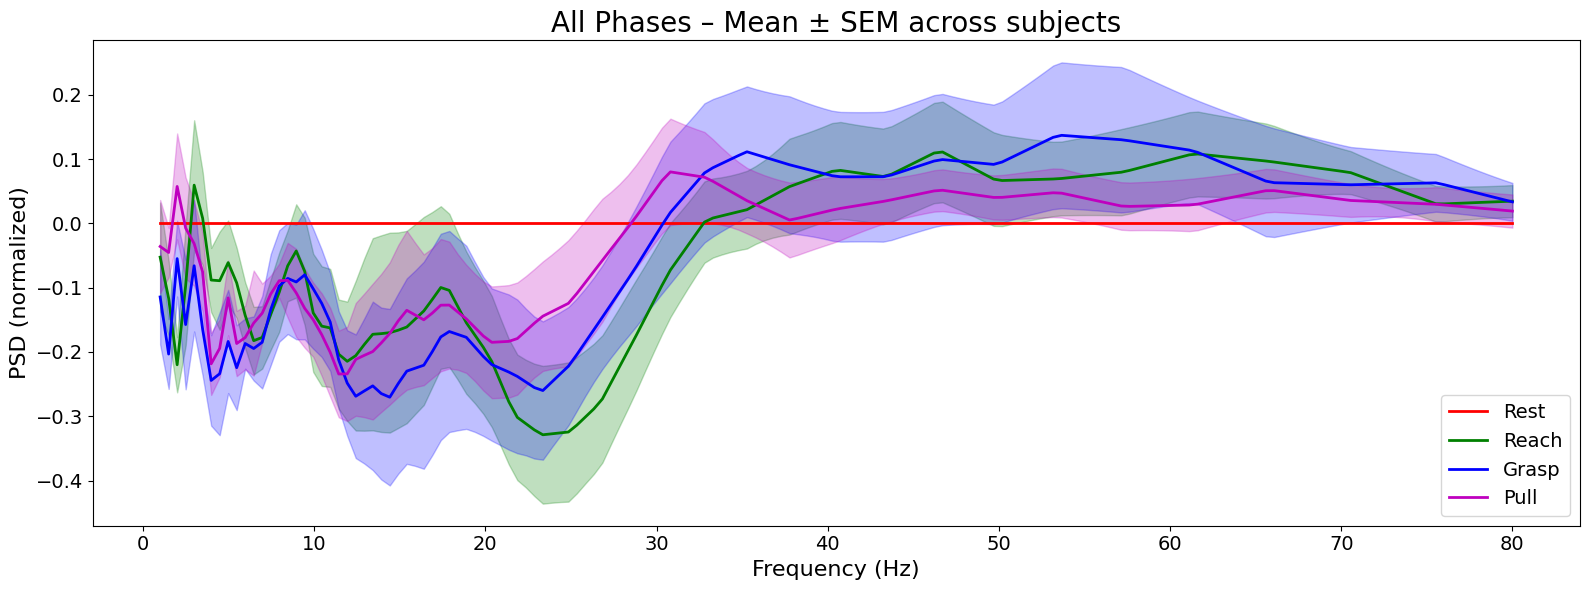

In [27]:
# ============================================================
# 📊 PLOT FINALE: TUTTE LE FASI INSIEME (Mean ± SEM soggetti)
# ============================================================

plt.figure(figsize=(16,6))

for phase in phase_names:

    # Ricostruzione PSD mediani per soggetti (come fatto nei pairwise)
    n_subjects = len(subject_list)
    psd_all_phase = np.zeros((n_subjects, len(freq_uniform)))

    for s_idx, subj_id in enumerate(subject_list):
        f_orig = data_dict[subj_id]['freqs_cutted']
        psd_orig = data_dict[subj_id]['PSD_norm_median'][phase]

        # Interpolazione sulle freq_uniform
        f_interp = interp1d(f_orig, psd_orig, kind='linear', fill_value='extrapolate')
        psd_all_phase[s_idx, :] = f_interp(freq_uniform)

    # Media e SEM
    m = np.mean(psd_all_phase, axis=0)
    s = np.std(psd_all_phase, axis=0, ddof=1) / np.sqrt(n_subjects)

    # Plot
    plt.plot(freq_uniform, m, color=phase_colors[phase], linewidth=2, label=phase)
    plt.fill_between(freq_uniform, m - s, m + s,
                     color=phase_colors[phase], alpha=0.25)


plt.title("All Phases – Mean ± SEM across subjects", fontsize=20)
plt.xlabel("Frequency (Hz)", fontsize=16)
plt.ylabel("PSD (normalized)", fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.grid(False)
plt.tight_layout()
plt.show()


In [28]:
print("\n\n=== SIGNIFICANT BANDS (all phase pairs) ===")
for k, v in SIGNIFICANT_BANDS.items():
    print(k, ":", v)



=== SIGNIFICANT BANDS (all phase pairs) ===
Rest_vs_Reach : [{'low_freq': 19.38364779874214, 'high_freq': 29.32075471698113, 'p_value': 0.0068}, {'low_freq': 32.79874213836478, 'high_freq': 79.50314465408805, 'p_value': 0.0001}]
Rest_vs_Grasp : [{'low_freq': 29.32075471698113, 'high_freq': 78.50943396226415, 'p_value': 0.0001}]
Rest_vs_Pull : [{'low_freq': 26.836477987421382, 'high_freq': 80.0, 'p_value': 0.0001}]
Reach_vs_Grasp : [{'low_freq': 20.87421383647799, 'high_freq': 36.276729559748425, 'p_value': 0.0074}]
Reach_vs_Pull : [{'low_freq': 56.64779874213836, 'high_freq': 71.55345911949685, 'p_value': 0.0165}, {'low_freq': 19.88050314465409, 'high_freq': 31.80503144654088, 'p_value': 0.0058}]
Grasp_vs_Pull : [{'low_freq': 32.79874213836478, 'high_freq': 43.23270440251572, 'p_value': 0.0423}, {'low_freq': 52.672955974842765, 'high_freq': 69.06918238993711, 'p_value': 0.0197}]


In [32]:
import numpy as np
from scipy.stats import wilcoxon, shapiro, ttest_rel
import scipy.stats as stats


phase_names = ['Rest', 'Reach', 'Grasp', 'Pull']
phase_pairs = [(phase_names[i], phase_names[j]) 
               for i in range(len(phase_names)) 
               for j in range(i+1, len(phase_names))]

STATS = {}

for phaseA, phaseB in phase_pairs:

    pair_key = f"{phaseA}_vs_{phaseB}"
    if pair_key not in SIGNIFICANT_BANDS:
        continue

    print(f"\n=== {pair_key} ===")

    bands = SIGNIFICANT_BANDS[pair_key]
    STATS[pair_key] = []

    for band in bands:

        low_f = band['low_freq']
        high_f = band['high_freq']

        vals_A = []
        vals_B = []

        # --- Trova lunghezza frequenze minima tra i soggetti ---
        min_len = min([len(data_dict[subj_id]['freqs']) for subj_id in subject_list])
        freqs = data_dict[subject_list[0]]['freqs'][:min_len]

        for subj_id in subject_list:

            mask = (freqs >= low_f) & (freqs <= high_f)

            #psd_A = data_dict[subj_id]['PSD_norm_median'][phaseA][:min_len]
            #psd_B = data_dict[subj_id]['PSD_norm_median'][phaseB][:min_len]

            psd_A_all = data_dict[subj_id]['PSD_trials_norm'][phaseA][:min_len,:]*100
            psd_B_all = data_dict[subj_id]['PSD_trials_norm'][phaseB][:min_len,:]*100

            band_mean_A = np.mean(psd_A_all[mask], axis=0)
            band_mean_B = np.mean(psd_B_all[mask], axis=0)

            vals_A.append(np.median(band_mean_A, axis=0))
            vals_B.append(np.median(band_mean_B, axis=0))

        vals_A = np.array(vals_A)
        vals_B = np.array(vals_B)

        diffs = vals_A - vals_B


        # distribuzione ~ normale → usare t-test
        stat, p_val = ttest_rel(vals_A, vals_B)
        chosen_test = "paired t-test"

        STATS[pair_key].append({
            "band": (low_f, high_f),
            "test_used": chosen_test,
            "p_value": p_val,
            "median_A": np.median(vals_A),
            "median_B": np.median(vals_B)
        })

        print(f"Banda {low_f}-{high_f} Hz:")
        print(f"  Test = {chosen_test}, p = {p_val:.5f}")
        print(f"  Median A={np.median(vals_A):.4f}, Median B={np.median(vals_B):.4f}")


=== Rest_vs_Reach ===
Banda 19.38364779874214-29.32075471698113 Hz:
  Test = paired t-test, p = 0.02930
  Median A=-0.0000, Median B=-14.4910
Banda 32.79874213836478-79.50314465408805 Hz:
  Test = paired t-test, p = 0.15260
  Median A=0.0000, Median B=2.5980

=== Rest_vs_Grasp ===
Banda 29.32075471698113-78.50943396226415 Hz:
  Test = paired t-test, p = 0.16526
  Median A=0.0000, Median B=4.1636

=== Rest_vs_Pull ===
Banda 26.836477987421382-80.0 Hz:
  Test = paired t-test, p = 0.04690
  Median A=0.0000, Median B=6.3851

=== Reach_vs_Grasp ===
Banda 20.87421383647799-36.276729559748425 Hz:
  Test = paired t-test, p = 0.30244
  Median A=-7.2915, Median B=-7.0083

=== Reach_vs_Pull ===
Banda 56.64779874213836-71.55345911949685 Hz:
  Test = paired t-test, p = 0.31386
  Median A=2.2155, Median B=5.5095
Banda 19.88050314465409-31.80503144654088 Hz:
  Test = paired t-test, p = 0.02754
  Median A=-11.6490, Median B=-1.6030

=== Grasp_vs_Pull ===
Banda 32.79874213836478-43.23270440251572 Hz:


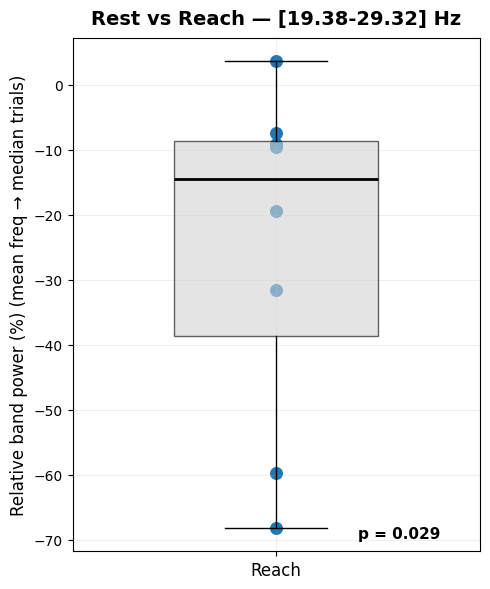

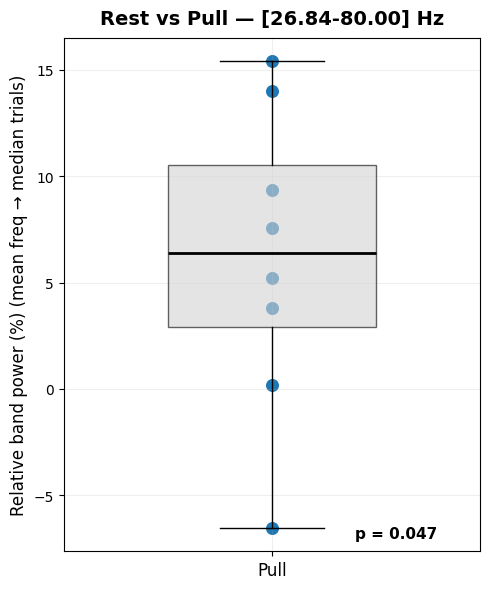

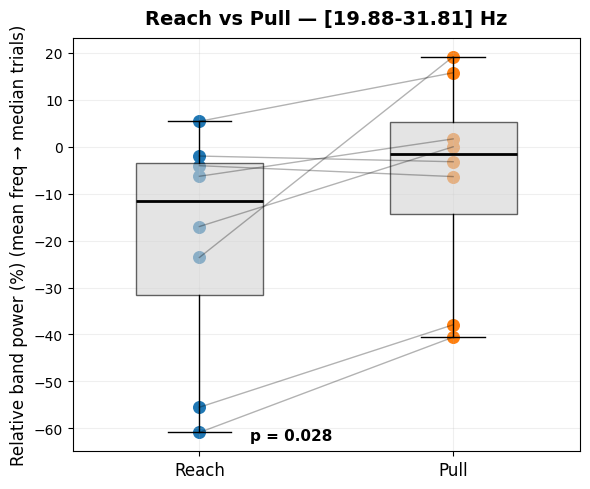

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# === Plot dei risultati per ogni banda significativa ===
for phaseA, phaseB in phase_pairs:

    pair_key = f"{phaseA}_vs_{phaseB}"
    if pair_key not in STATS:
        continue

    min_len = min([len(data_dict[subj_id]['freqs']) for subj_id in subject_list])
    freqs = data_dict[subject_list[0]]['freqs'][:min_len]

    for item in STATS[pair_key]:

        if item["p_value"] >= 0.05:
            continue  # skip non-significant

        low_f, high_f = item["band"]
        title_band = f"[{low_f:.2f}-{high_f:.2f}] Hz"

        vals_A = []
        vals_B = []

        for subj_id in subject_list:
            mask = (freqs >= low_f) & (freqs <= high_f)

            psd_A_all = data_dict[subj_id]['PSD_trials_norm'][phaseA][:min_len,:]*100
            psd_B_all = data_dict[subj_id]['PSD_trials_norm'][phaseB][:min_len,:]*100

            band_mean_A = np.mean(psd_A_all[mask], axis=0)
            band_mean_B = np.mean(psd_B_all[mask], axis=0)

            vals_A.append(np.median(band_mean_A))
            vals_B.append(np.median(band_mean_B))

        vals_A = np.array(vals_A)
        vals_B = np.array(vals_B)

        # 🔥 Solo Rest → un boxplot
        if phaseA == "Rest" or phaseB == "Rest":
            if phaseA == "Rest":
                phase_plot = phaseB
                vals_plot = vals_B - vals_A
            else:
                phase_plot = phaseA
                vals_plot = vals_A - vals_B

            boxprops = dict(facecolor='white', edgecolor='black', linewidth=1.2)
            medianprops = dict(color='black', linewidth=2)
            whiskerprops = dict(color='black', linewidth=1)
            capprops = dict(color='black', linewidth=1)

            plt.figure(figsize=(5, 6))  # verticale un po' più lunga
            plt.boxplot(vals_plot, positions=[1], widths=0.5,
                        showfliers=False, patch_artist=True,
                        boxprops=dict(facecolor='lightgray', alpha=0.6),
                        medianprops=medianprops, whiskerprops=whiskerprops,
                        capprops=capprops)

            plt.scatter(np.full(len(vals_plot), 1), vals_plot, s=70)
            plt.xticks([1], [phase_plot], fontsize=12)
            plt.ylabel("Relative band power (%) (mean freq → median trials)", fontsize=12)
            plt.title(f"{phaseA} vs {phaseB} — {title_band}", fontsize=14, fontweight='bold', pad=10)
            plt.grid(alpha=0.2)

            # p-value in basso a destra
            y_min, y_max = plt.ylim()
            plt.text(1.20, y_min + 0.02*(y_max - y_min),
                     f"p = {item['p_value']:.3f}",
                     ha='left', va='bottom', fontsize=11, fontweight='bold')

            plt.tight_layout()
            plt.show()
            continue

        # 🔁 Confronti NON Rest → due boxplot
        plt.figure(figsize=(6,5))
        positions=[1,2]

        plt.boxplot([vals_A, vals_B], positions=positions, widths=0.5,
                    showfliers=False, patch_artist=True,
                    boxprops=dict(facecolor='lightgray', alpha=0.6),
                    medianprops=medianprops, whiskerprops=whiskerprops,
                    capprops=capprops)

        plt.scatter(np.full(len(vals_A), positions[0]), vals_A, s=70)
        plt.scatter(np.full(len(vals_B), positions[1]), vals_B, s=70)

        # collegamenti
        for a,b in zip(vals_A, vals_B):
            plt.plot([positions[0], positions[1]], [a,b], color='black', alpha=0.3, linewidth=1)

        plt.xticks(positions, [phaseA, phaseB], fontsize=12)
        plt.ylabel("Relative band power (%) (mean freq → median trials)", fontsize=12)
        plt.title(f"{phaseA} vs {phaseB} — {title_band}", fontsize=14, fontweight='bold', pad=10)
        plt.grid(alpha=0.2)

        # p-value in basso a destra
        y_min, y_max = plt.ylim()
        plt.text(1.20, y_min + 0.02*(y_max - y_min),
                 f"p = {item['p_value']:.3f}",
                 ha='left', va='bottom', fontsize=11, fontweight='bold')

        plt.tight_layout()
        plt.show()


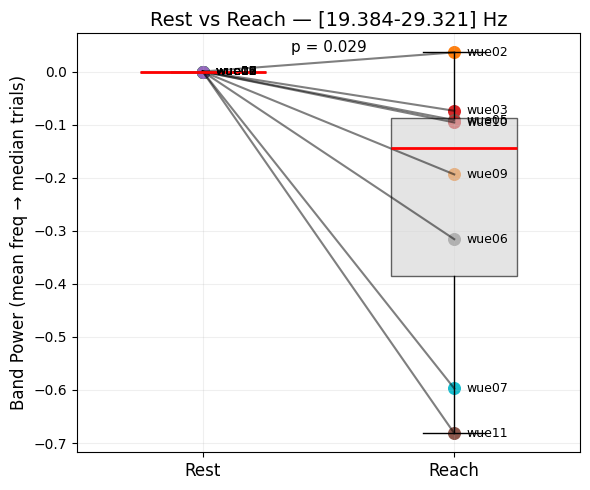

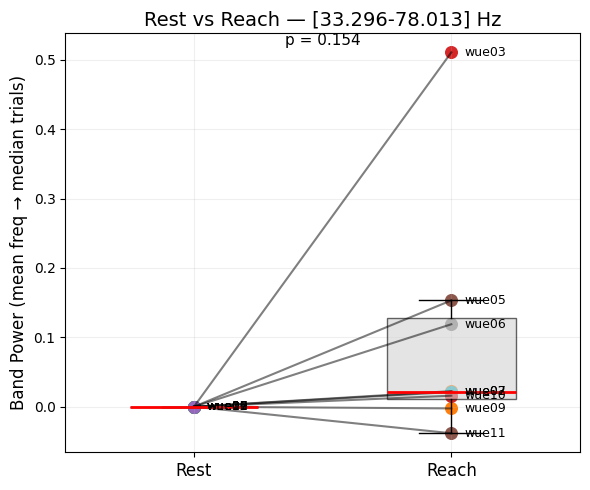

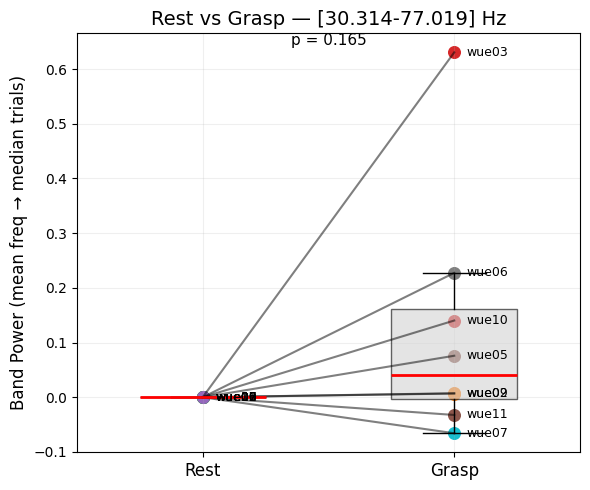

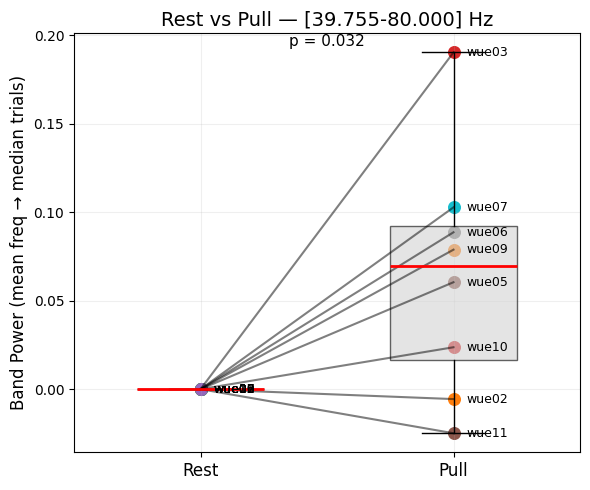

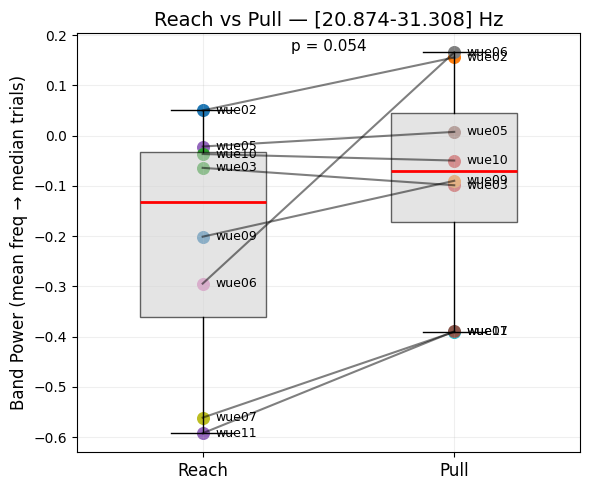

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# === Plot dei risultati per ogni banda significativa ===
for phaseA, phaseB in phase_pairs:

    pair_key = f"{phaseA}_vs_{phaseB}"
    if pair_key not in STATS:
        continue

    min_len = min([len(data_dict[subj_id]['freqs']) for subj_id in subject_list])
    freqs = data_dict[subject_list[0]]['freqs'][:min_len]

    for item in STATS[pair_key]:

        low_f, high_f = item["band"]
        title_band = f"[{low_f:.3f}-{high_f:.3f}] Hz"

        vals_A = []
        vals_B = []

        for subj_id in subject_list:
            mask = (freqs>=low_f)&(freqs<=high_f)

            psd_A_all = data_dict[subj_id]['PSD_trials_norm'][phaseA][:min_len,:]
            psd_B_all = data_dict[subj_id]['PSD_trials_norm'][phaseB][:min_len,:]

            band_mean_A = np.mean(psd_A_all[mask],axis=0)
            band_mean_B = np.mean(psd_B_all[mask],axis=0)

            vals_A.append(np.median(band_mean_A))
            vals_B.append(np.median(band_mean_B))

        vals_A = np.array(vals_A); vals_B = np.array(vals_B)

        # === FIGURA ===
        plt.figure(figsize=(6,5))
        positions=[1,2]

        plt.boxplot([vals_A, vals_B], positions=positions, widths=0.5,
                    showfliers=False, patch_artist=True,
                    boxprops=dict(facecolor='lightgray',alpha=0.6),
                    medianprops=dict(color='red',linewidth=2))

        # Scatter con etichette soggetto 🔥
        for i,(a,b) in enumerate(zip(vals_A, vals_B)):
            subj = subject_list[i]

            # Plot puntini
            plt.scatter(positions[0], a, s=70)
            plt.scatter(positions[1], b, s=70)

            # Etichette vicino al punto
            plt.text(positions[0]+0.05, a, subj, fontsize=9, va='center')
            plt.text(positions[1]+0.05, b, subj, fontsize=9, va='center')

            # Linea che collega A→B
            plt.plot([positions[0], positions[1]], [a, b], color='black', alpha=0.5)

        plt.xticks(positions,[phaseA,phaseB],fontsize=12)
        plt.ylabel("Band Power (mean freq → median trials)",fontsize=12)
        plt.title(f"{phaseA} vs {phaseB} — {title_band}",fontsize=14)
        plt.grid(alpha=0.2)

        # 🔥 p-value vicino al centro
        y_pos = max(max(vals_A),max(vals_B)) * 1.02
        plt.text(1.5, y_pos, f"p = {item['p_value']:.3f}",
                ha='center',fontsize=11)

        plt.tight_layout()
        plt.show()
